# MecaniQA - OAT 3 completa

Equipe Macapá. Este notebook reúne os encontros de 30/09, 07/10, 14/10 e 21/10/2026.

No Colab, abra este arquivo e execute as células de cima para baixo. Quando solicitado, envie somente `mecaniqa_dataset.xlsx`. O código está todo incluído. Localmente, a planilha pode ficar em `datasets`.

As células do dia 7 usam o grid decidido pela equipe: 50, 100 e 200 árvores e profundidades 3, 5 e 10 para Random Forest. O notebook `oat3_gridsearch.ipynb` continua disponível para apresentar somente o dia 7.

## Preparação e proteção temporal

Previsão das trocas de óleo de amanhã usando informações disponíveis até hoje. Corte cronológico 80/20 dos exemplos com alvo válido. A imputação e a escala são aprendidas em cada treino dentro do Pipeline. Não usamos interpolação nem preenchimento com valores futuros no modelo.

As buscas usam cinco folds de `TimeSeriesSplit(gap=1)`, protegendo a disponibilidade do alvo de amanhã. Os 20% finais ficam separados da escolha dos modelos e dos parâmetros. A previsão é diária: cada nova observação pode ser usada para prever o dia seguinte.

O K-Fold comum, mesmo sem embaralhar, pode treinar com períodos posteriores ao bloco de validação. O TimeSeriesSplit mantém o treino anterior à validação.

In [1]:
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV, ParameterGrid, TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


ARQUIVO_DADOS = Path("datasets/mecaniqa_dataset.xlsx")
if not ARQUIVO_DADOS.exists():
    ARQUIVO_DADOS = Path("mecaniqa_dataset.xlsx")
if not ARQUIVO_DADOS.exists():
    try:
        from google.colab import files  # pyright: ignore[reportMissingImports]
    except ImportError as erro:
        raise FileNotFoundError("Coloque mecaniqa_dataset.xlsx na pasta datasets ou ao lado do notebook.") from erro
    print("Selecione mecaniqa_dataset.xlsx do seu computador.")
    files.upload()
    if not ARQUIVO_DADOS.exists():
        raise FileNotFoundError("Envie a planilha com o nome mecaniqa_dataset.xlsx.")


def carregar_dados():
    df = pd.read_excel(ARQUIVO_DADOS)
    df["Data"] = pd.to_datetime(df["Data"], errors="raise")
    df = df.sort_values("Data").set_index("Data")

    if df.index.hasnans or df.index.has_duplicates:
        raise ValueError("A planilha precisa ter datas válidas e sem duplicatas.")
    if not df.index.to_series().diff().dropna().eq(pd.Timedelta(days=1)).all():
        raise ValueError("A planilha precisa ter uma linha por dia, sem intervalos.")

    # Quantidades negativas são entradas inválidas; a imputação ocorre no pipeline.
    colunas = ["Trocas_Oleo", "Manutencao_Motor"]
    df[colunas] = df[colunas].mask(df[colunas] < 0)
    dados = df[colunas].copy()
    dados["Demanda_Amanha"] = df["Trocas_Oleo"].shift(-1)

    # Previsões de amanhã usando somente informações disponíveis até hoje.
    dados["Naive"] = df["Trocas_Oleo"].ffill()
    dados["Media_Movel_7"] = df["Trocas_Oleo"].ffill().rolling(7, min_periods=1).mean()
    dados = dados.dropna(subset=["Demanda_Amanha"])
    return dados, colunas


def criar_pipeline(modelo):
    return Pipeline([
        ("imputacao", SimpleImputer(strategy="median")),
        ("padronizacao", StandardScaler()),
        ("modelo", modelo),
    ])


def calcular_metricas(y_real, previsao):
    real = np.asarray(y_real, dtype=float)
    previsto = np.asarray(previsao, dtype=float)
    positivos = real > 0
    mape = (
        np.mean(np.abs((real[positivos] - previsto[positivos]) / real[positivos])) * 100
        if positivos.any() else np.nan
    )
    return {
        "MAE": mean_absolute_error(real, previsto),
        "RMSE": np.sqrt(mean_squared_error(real, previsto)),
        "MAPE (demanda > 0) %": mape,
    }



from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import (
    GridSearchCV,
    ParameterGrid,
    RandomizedSearchCV,
    TimeSeriesSplit,
    cross_val_score,
)



GRIDS = {
    "Random Forest": {
        "modelo__n_estimators": [50, 100, 200],
        "modelo__max_depth": [3, 5, 10],
    },
    "Gradient Boosting": {
        "modelo__n_estimators": [100, 200, 300],
        "modelo__max_depth": [2, 3],
        "modelo__learning_rate": [0.05, 0.1],
    },
}
N_ITER = 6
PASTA_RESULTADOS = Path("output/oat3")


def preparar_experimento():
    dados, colunas = carregar_dados()
    corte = int(len(dados) * 0.8)
    treino, teste = dados.iloc[:corte], dados.iloc[corte:]
    cv = TimeSeriesSplit(n_splits=5, gap=1)

    # Um alvo em t+1 deve estar disponível antes da primeira referência da validação.
    for indices_treino, indices_validacao in cv.split(treino):
        ultima_data_alvo = treino.index[indices_treino[-1]] + pd.Timedelta(days=1)
        primeira_referencia = treino.index[indices_validacao[0]]
        if ultima_data_alvo >= primeira_referencia:
            raise ValueError("O fold não respeita a disponibilidade temporal do alvo.")

    print(f"Exemplos válidos: {len(dados)} | Treino: {len(treino)} | Teste: {len(teste)}")
    print("Previsão diária de amanhã com informações disponíveis até hoje.")
    print("Escolha dos modelos e buscas: somente no treino, em cinco folds temporais.")
    return {
        "X_train": treino[colunas],
        "y_train": treino["Demanda_Amanha"],
        "X_test": teste[colunas],
        "y_test": teste["Demanda_Amanha"],
        "teste": teste,
        "cv": cv,
    }


def comparar_modelos(experimento):
    # Apenas a semente é fixada; os hiperparâmetros de aprendizado são os padrões.
    modelos = {
        "Random Forest": criar_pipeline(RandomForestRegressor(random_state=42)),
        "Gradient Boosting": criar_pipeline(GradientBoostingRegressor(random_state=42)),
    }
    rmse_cv = {}
    for nome, modelo in modelos.items():
        scores = cross_val_score(
            modelo,
            experimento["X_train"],
            experimento["y_train"],
            cv=experimento["cv"],
            scoring="neg_root_mean_squared_error",
            n_jobs=1,
            error_score="raise",
        )
        rmse_cv[nome] = -scores.mean()
        print(f"{nome} padrão - RMSE médio na validação: {rmse_cv[nome]:.4f}")
    escolhido = min(rmse_cv, key=rmse_cv.get)
    print("Modelo escolhido pela validação:", escolhido)
    return modelos, escolhido, rmse_cv


def executar_grid(experimento, modelo, grid):
    busca = GridSearchCV(
        modelo,
        param_grid=grid,
        cv=experimento["cv"],
        scoring="neg_root_mean_squared_error",
        n_jobs=1,
        refit=True,
        error_score="raise",
    )
    inicio = perf_counter()
    busca.fit(experimento["X_train"], experimento["y_train"])
    segundos = perf_counter() - inicio
    print(f"Grid Search: {len(ParameterGrid(grid))} combinações, {segundos:.2f} segundos")
    print("best_params_:", busca.best_params_)
    print(f"RMSE médio na validação: {-busca.best_score_:.4f}")
    return {"busca": busca, "segundos": segundos, "candidatos": len(ParameterGrid(grid))}


def executar_random(experimento, modelo, grid, n_iter=N_ITER):
    total = len(ParameterGrid(grid))
    if not isinstance(n_iter, int) or not 1 <= n_iter <= total:
        raise ValueError(f"n_iter deve ser inteiro entre 1 e {total}.")
    busca = RandomizedSearchCV(
        modelo,
        param_distributions=grid,
        n_iter=n_iter,
        cv=experimento["cv"],
        scoring="neg_root_mean_squared_error",
        random_state=42,
        n_jobs=1,
        refit=True,
        error_score="raise",
    )
    inicio = perf_counter()
    busca.fit(experimento["X_train"], experimento["y_train"])
    segundos = perf_counter() - inicio
    print(f"Random Search: n_iter={n_iter}, {segundos:.2f} segundos")
    print("best_params_:", busca.best_params_)
    print(f"RMSE médio na validação: {-busca.best_score_:.4f}")
    return {"busca": busca, "segundos": segundos, "candidatos": n_iter}


def reducao_percentual(erro_inicial, erro_final):
    if erro_inicial == 0:
        return float("nan")
    return (erro_inicial - erro_final) / erro_inicial * 100


def avaliar_teste(experimento, modelos, escolhido, grid, random):
    metodos = {"Grid Search": grid, "Random Search": random}
    # Empates de validação mantêm o Grid, sem consultar o teste final.
    melhor_metodo = min(metodos, key=lambda nome: -metodos[nome]["busca"].best_score_)
    nome_final = f"{escolhido} - {melhor_metodo}"

    y_test = experimento["y_test"]
    previsoes = pd.DataFrame(index=y_test.index + pd.Timedelta(days=1))
    previsoes.index.name = "Data_da_previsao"
    previsoes["Real"] = y_test.to_numpy()
    previsoes["Naive"] = experimento["teste"]["Naive"].to_numpy()
    previsoes["Média móvel 7 dias"] = experimento["teste"]["Media_Movel_7"].to_numpy()

    for nome, modelo in modelos.items():
        modelo.fit(experimento["X_train"], experimento["y_train"])
        previsoes[f"{nome} padrão"] = modelo.predict(experimento["X_test"])
    referencia = criar_pipeline(RandomForestRegressor(n_estimators=200, random_state=42))
    referencia.fit(experimento["X_train"], experimento["y_train"])
    previsoes["Random Forest anterior (200 árvores)"] = referencia.predict(experimento["X_test"])
    for nome, resultado in metodos.items():
        previsoes[f"{escolhido} - {nome}"] = resultado["busca"].predict(experimento["X_test"])

    metricas = pd.DataFrame({
        nome: calcular_metricas(previsoes["Real"], previsoes[nome])
        for nome in previsoes.columns if nome != "Real"
    }).T.rename_axis("Modelo")
    comparacao = pd.DataFrame({
        nome: {
            "Tempo (s)": resultado["segundos"],
            "Combinações": resultado["candidatos"],
            "RMSE validação": -resultado["busca"].best_score_,
            "RMSE teste": metricas.loc[f"{escolhido} - {nome}", "RMSE"],
        }
        for nome, resultado in metodos.items()
    }).T.rename_axis("Método")

    cenarios = metricas.loc[["Média móvel 7 dias", f"{escolhido} padrão", nome_final]].copy()
    cenarios.index = ["Baseline antigo (MM7)", "ML inicial padrão", f"ML ajustado ({melhor_metodo})"]
    rmse_grid = metricas.loc[f"{escolhido} - Grid Search", "RMSE"]
    ganho_referencia = reducao_percentual(
        metricas.loc["Random Forest anterior (200 árvores)", "RMSE"], rmse_grid
    )
    ganho_inicial = reducao_percentual(
        metricas.loc[f"{escolhido} padrão", "RMSE"], metricas.loc[nome_final, "RMSE"]
    )
    print("\nMétricas no mesmo teste final:")
    print(metricas.round(4).to_string())
    print("\nTempo e erro das duas buscas:")
    print(comparacao.round(4).to_string())
    print(f"\nMétodo escolhido pela validação: {melhor_metodo}")
    print(f"Redução do RMSE ajustado versus inicial padrão: {ganho_inicial:.2f}%")
    print(f"Redução do RMSE do Grid versus referência anterior (200 árvores): {ganho_referencia:.2f}%")
    print(f"MAPE: {int((y_test > 0).sum())} de {len(y_test)} dias com demanda maior que zero.")
    return {
        "metricas": metricas,
        "cenarios": cenarios,
        "comparacao": comparacao,
        "previsoes": previsoes,
        "modelo_escolhido": escolhido,
        "melhor_metodo": melhor_metodo,
        "nome_final": nome_final,
        "reducao_inicial_percentual": ganho_inicial,
        "reducao_referencia_percentual": ganho_referencia,
        "grid": grid,
        "random": random,
    }


def conclusao_markdown(resultado):
    c = resultado["comparacao"]
    g, r = c.loc["Grid Search"], c.loc["Random Search"]
    diferenca_tempo = g["Tempo (s)"] - r["Tempo (s)"]
    diferenca_erro = r["RMSE teste"] - g["RMSE teste"]
    if diferenca_tempo > 0:
        texto_tempo = f"O Random Search levou {diferenca_tempo:.2f} segundos a menos."
    else:
        texto_tempo = f"O Random Search levou {-diferenca_tempo:.2f} segundos a mais."
    texto_erro = (
        f"Seu RMSE no teste foi {diferenca_erro:.4f} maior."
        if diferenca_erro > 0 else
        f"Seu RMSE no teste foi {-diferenca_erro:.4f} menor."
        if diferenca_erro < 0 else "As duas buscas tiveram o mesmo RMSE no teste."
    )
    mae_mm7 = resultado["metricas"].loc["Média móvel 7 dias", "MAE"]
    mae_final = resultado["metricas"].loc[resultado["nome_final"], "MAE"]
    return (
        "# MecaniQA - conclusão da OAT 3\n\n"
        f"O modelo escolhido na validação foi **{resultado['modelo_escolhido']}**. "
        "As duas buscas utilizaram o mesmo espaço de parâmetros, cinco folds de "
        "TimeSeriesSplit com gap=1, o mesmo RMSE e uma única tarefa de processamento. "
        "Os tempos abaixo medem somente o fit de cada busca, incluindo o refit.\n\n"
        f"- Grid Search: {int(g['Combinações'])} combinações, {g['Tempo (s)']:.2f} segundos, "
        f"RMSE de validação {g['RMSE validação']:.4f} e RMSE de teste {g['RMSE teste']:.4f}.\n"
        f"- Random Search: {int(r['Combinações'])} combinações, {r['Tempo (s)']:.2f} segundos, "
        f"RMSE de validação {r['RMSE validação']:.4f} e RMSE de teste {r['RMSE teste']:.4f}.\n\n"
        f"{texto_tempo} {texto_erro} A escolha final foi **{resultado['melhor_metodo']}**, "
        "pelo RMSE na validação, antes de consultar o teste; em caso de empate, "
        "mantemos o Grid conforme a regra definida no experimento.\n\n"
        "Random Search é uma opção quando o espaço de parâmetros é grande e há limite "
        "de processamento. Nesta base pequena, a diferença de tempo é uma medição desta "
        "execução; é necessário observar conjuntamente o custo e o erro, sem garantir "
        "que uma busca será sempre mais rápida ou mais precisa.\n\n"
        f"O RMSE final mudou {resultado['reducao_inicial_percentual']:.2f}% em relação ao "
        "modelo inicial padrão (percentual positivo indica redução; negativo indica piora). "
        f"O Grid reduziu o RMSE em {resultado['reducao_referencia_percentual']:.2f}% frente "
        "ao Random Forest anterior de 200 árvores, reexecutado nas mesmas condições.\n\n"
        "Para explicar o resultado ao dono da oficina, o MAE é a medida mais direta: "
        f"a média móvel errou {mae_mm7:.2f} trocas de óleo por dia, enquanto o modelo "
        f"ajustado errou {mae_final:.2f}. O RMSE destaca erros maiores. O MAPE considera "
        "somente dias com demanda positiva e deve ser lido junto das outras métricas. "
        "Esses erros são quantidades de serviços; não medem lucro em reais sem custos "
        "de falta e excesso de estoque.\n\n"
        "O teste final contém 145 dias. Esta avaliação prevê um dia por vez usando "
        "observações disponíveis até o dia anterior à previsão; não é uma previsão "
        "de todo o período de teste de uma única vez.\n"
    )


def criar_grafico(resultado):
    dados = resultado["previsoes"].tail(60)
    fig, ax = plt.subplots(figsize=(13, 5))
    curvas = {
        "Real": "Trocas de óleo reais",
        "Média móvel 7 dias": "Baseline: média móvel 7 dias",
        f"{resultado['modelo_escolhido']} padrão": "Modelo ML inicial",
        resultado["nome_final"]: "Modelo ML ajustado",
    }
    for coluna, legenda in curvas.items():
        ax.plot(dados.index, dados[coluna], label=legenda, linewidth=2 if coluna == "Real" else 1.5)
    ax.set_title("MecaniQA - comparação no teste final (últimos 60 dias)")
    ax.set_xlabel("Data prevista")
    ax.set_ylabel("Quantidade de trocas de óleo")
    ax.legend()
    ax.grid(alpha=0.25)
    fig.autofmt_xdate()
    fig.tight_layout()
    return fig


def salvar_resultados(resultado, figura, pasta=PASTA_RESULTADOS):
    pasta = Path(pasta)
    pasta.mkdir(parents=True, exist_ok=True)
    for nome in ["metricas", "cenarios", "comparacao", "previsoes"]:
        resultado[nome].to_csv(pasta / f"{nome}.csv", encoding="utf-8-sig")
    figura.savefig(pasta / "comparacao_final.png", dpi=160)
    (pasta / "conclusao.md").write_text(conclusao_markdown(resultado), encoding="utf-8")
    print("Resultados salvos em:", pasta.resolve())



In [2]:
experimento = preparar_experimento()

Exemplos válidos: 724 | Treino: 579 | Teste: 145
Previsão diária de amanhã com informações disponíveis até hoje.
Escolha dos modelos e buscas: somente no treino, em cinco folds temporais.


## 30/09 - modelos iniciais

Random Forest e Gradient Boosting capturam relações não lineares nos dados tabulares. A semente é 42; os hiperparâmetros de aprendizado são os padrões. O menor RMSE médio na validação do treino determina o modelo a ajustar.

Sazonalidade não é garantida apenas pela escolha de árvores: depende das informações oferecidas ao modelo. Mantemos as duas entradas do projeto para comparar o efeito dos parâmetros sem adicionar outras features. As métricas de teste e a comparação com baselines aparecem na tabela final.

In [3]:
modelos, escolhido, rmse_cv = comparar_modelos(experimento)
pd.Series(rmse_cv, name="RMSE médio de validação")

Random Forest padrão - RMSE médio na validação: 11.9982
Gradient Boosting padrão - RMSE médio na validação: 12.4709
Modelo escolhido pela validação: Random Forest


Random Forest        11.998227
Gradient Boosting    12.470948
Name: RMSE médio de validação, dtype: float64

## 07/10 - Grid Search

**Decisão sobre o grid:** para Random Forest, `n_estimators=[50, 100, 200]` e `max_depth=[3, 5, 10]`. São nove combinações. Limitar a profundidade controla a complexidade e reduz o risco de overfitting; a validação informa qual configuração funciona melhor.

Se o Gradient Boosting vencer a comparação inicial, seu grid usa 100, 200 e 300 árvores, profundidades 2 e 3 e taxas de aprendizagem 0,05 e 0,1.

**Proteção temporal:** o GridSearchCV recebe o TimeSeriesSplit no argumento `cv` e o fit usa somente o treino. A saída mostra `best_params_`. Na tabela final, o ganho é calculado contra o modelo padrão e, separadamente, contra a referência anterior de 200 árvores.

In [4]:
grid = executar_grid(experimento, modelos[escolhido], GRIDS[escolhido])

Grid Search: 9 combinações, 4.65 segundos
best_params_: {'modelo__max_depth': 3, 'modelo__n_estimators': 50}
RMSE médio na validação: 10.1835


In [5]:
tabela_grid = pd.DataFrame(grid["busca"].cv_results_)
tabela_grid["RMSE validação"] = -tabela_grid["mean_test_score"]
tabela_grid[["params", "RMSE validação", "rank_test_score"]].sort_values("rank_test_score")

,params,RMSE validação,rank_test_score
0,"{'modelo__max_depth': 3, 'modelo__n_estimators...",10.183487,1
2,"{'modelo__max_depth': 3, 'modelo__n_estimators...",10.349628,2
1,"{'modelo__max_depth': 3, 'modelo__n_estimators...",10.357966,3
3,"{'modelo__max_depth': 5, 'modelo__n_estimators...",10.904212,4
5,"{'modelo__max_depth': 5, 'modelo__n_estimators...",11.042202,5
4,"{'modelo__max_depth': 5, 'modelo__n_estimators...",11.059741,6
6,"{'modelo__max_depth': 10, 'modelo__n_estimator...",11.649612,7
8,"{'modelo__max_depth': 10, 'modelo__n_estimator...",11.822365,8
7,"{'modelo__max_depth': 10, 'modelo__n_estimator...",11.842005,9


## 14/10 - Random Search: tempo versus erro

**Decisão da equipe:** quando há muitas combinações e um orçamento limitado de processamento, Random Search permite testar uma amostra do espaço. A redução do custo precisa ser confrontada com o erro observado.

Usamos `RandomizedSearchCV(n_iter=6, random_state=42)` no mesmo grid, com a mesma validação e `n_jobs=1` das duas buscas. Cada função mede somente o tempo de seu fit com `perf_counter`, incluindo o refit. Os resultados de tempo são próprios da máquina e da execução; não garantem a mesma vantagem em outras condições.

In [6]:
random = executar_random(experimento, modelos[escolhido], GRIDS[escolhido], n_iter=6)

Random Search: n_iter=6, 3.34 segundos
best_params_: {'modelo__n_estimators': 50, 'modelo__max_depth': 3}
RMSE médio na validação: 10.1835


## 21/10 - motor de métricas e comparação final

O melhor método é escolhido pelo RMSE de validação antes de consultar o teste. Empates mantêm o Grid. A rotina calcula MAE, RMSE e MAPE para o baseline, o modelo inicial e o ajustado e também apresenta os demais modelos para comparação.

**Interpretando o ganho:** MAE é a medida mais direta para o dono da oficina, porque expressa o erro médio em quantidade de serviços por dia. RMSE destaca erros grandes. MAPE só é definido para demanda diferente de zero: aqui usamos demanda positiva e informamos quantos dias foram incluídos. Para falar em lucro ou prejuízo em reais, seriam necessários custos de falta e excesso de estoque.

In [7]:
resultado = avaliar_teste(experimento, modelos, escolhido, grid, random)
resultado["metricas"].round(4)


Métricas no mesmo teste final:
                                         MAE    RMSE  MAPE (demanda > 0) %
Modelo                                                                    
Naive                                 6.4207  8.8517               26.6387
Média móvel 7 dias                    7.3478  8.1193               30.8942
Random Forest padrão                  7.0156  8.7241               29.7688
Gradient Boosting padrão              6.2699  7.8992               26.5733
Random Forest anterior (200 árvores)  7.0181  8.7263               29.7019
Random Forest - Grid Search           6.3321  7.7908               26.8577
Random Forest - Random Search         6.3321  7.7908               26.8577

Tempo e erro das duas buscas:
               Tempo (s)  Combinações  RMSE validação  RMSE teste
Método                                                           
Grid Search       4.6504          9.0         10.1835      7.7908
Random Search     3.3368          6.0         10.1835      7.790

,MAE,RMSE,MAPE (demanda > 0) %
Modelo,,,
Naive,6.4207,8.8517,26.6387
Média móvel 7 dias,7.3478,8.1193,30.8942
Random Forest padrão,7.0156,8.7241,29.7688
Gradient Boosting padrão,6.2699,7.8992,26.5733
Random Forest anterior (200 árvores),7.0181,8.7263,29.7019
Random Forest - Grid Search,6.3321,7.7908,26.8577
Random Forest - Random Search,6.3321,7.7908,26.8577


In [8]:
resultado["cenarios"].round(4)

,MAE,RMSE,MAPE (demanda > 0) %
Baseline antigo (MM7),7.3478,8.1193,30.8942
ML inicial padrão,7.0156,8.7241,29.7688
ML ajustado (Grid Search),6.3321,7.7908,26.8577


In [9]:
resultado["comparacao"].round(4)

,Tempo (s),Combinações,RMSE validação,RMSE teste
Método,,,,
Grid Search,4.6504,9.0,10.1835,7.7908
Random Search,3.3368,6.0,10.1835,7.7908


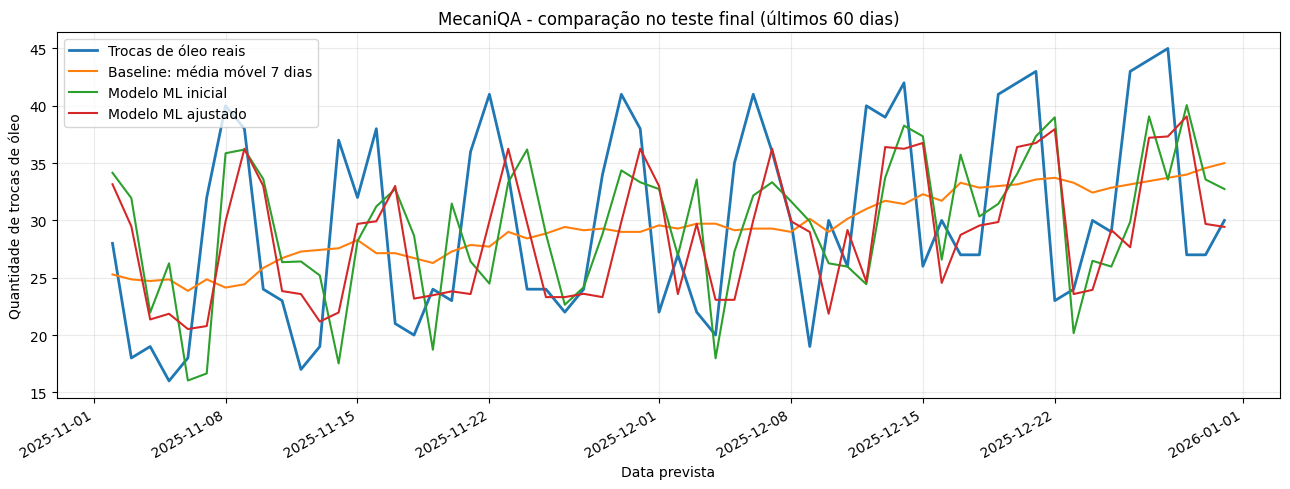

In [10]:
figura = criar_grafico(resultado)
plt.show()

## Conclusão medida para revisão do QA e do Arquiteto

O bloco abaixo é gerado a partir desta execução. Inclui os segundos de cada busca, a diferença entre os tempos e os erros e a comparação final. A equipe deve revisar a conclusão com os resultados visíveis.

In [11]:
from IPython.display import Markdown, display

display(Markdown(conclusao_markdown(resultado)))

# MecaniQA - conclusão da OAT 3

O modelo escolhido na validação foi **Random Forest**. As duas buscas utilizaram o mesmo espaço de parâmetros, cinco folds de TimeSeriesSplit com gap=1, o mesmo RMSE e uma única tarefa de processamento. Os tempos abaixo medem somente o fit de cada busca, incluindo o refit.

- Grid Search: 9 combinações, 4.65 segundos, RMSE de validação 10.1835 e RMSE de teste 7.7908.
- Random Search: 6 combinações, 3.34 segundos, RMSE de validação 10.1835 e RMSE de teste 7.7908.

O Random Search levou 1.31 segundos a menos. As duas buscas tiveram o mesmo RMSE no teste. A escolha final foi **Grid Search**, pelo RMSE na validação, antes de consultar o teste; em caso de empate, mantemos o Grid conforme a regra definida no experimento.

Random Search é uma opção quando o espaço de parâmetros é grande e há limite de processamento. Nesta base pequena, a diferença de tempo é uma medição desta execução; é necessário observar conjuntamente o custo e o erro, sem garantir que uma busca será sempre mais rápida ou mais precisa.

O RMSE final mudou 10.70% em relação ao modelo inicial padrão (percentual positivo indica redução; negativo indica piora). O Grid reduziu o RMSE em 10.72% frente ao Random Forest anterior de 200 árvores, reexecutado nas mesmas condições.

Para explicar o resultado ao dono da oficina, o MAE é a medida mais direta: a média móvel errou 7.35 trocas de óleo por dia, enquanto o modelo ajustado errou 6.33. O RMSE destaca erros maiores. O MAPE considera somente dias com demanda positiva e deve ser lido junto das outras métricas. Esses erros são quantidades de serviços; não medem lucro em reais sem custos de falta e excesso de estoque.

O teste final contém 145 dias. Esta avaliação prevê um dia por vez usando observações disponíveis até o dia anterior à previsão; não é uma previsão de todo o período de teste de uma única vez.


In [12]:
salvar_resultados(resultado, figura)
plt.close(figura)

Resultados salvos em: C:\Users\lenil\OneDrive\Documentos\GitHub\mecaniQA-MACAPA\.oat3-completa-check-tyu6twmh\output\oat3


## Entrega

Os CSVs, o gráfico e a conclusão são salvos em `output/oat3`. No Colab, use o painel de arquivos para baixá-los e salve uma cópia deste notebook no Drive.

A publicação na branch `main` é um passo separado: depois da revisão da equipe, selecione os arquivos de entrega para commit e push. A execução deste notebook não publica nada no GitHub.